# DuoT5 Reranking

This notebook mirrors the cross-encoder reranking pipeline, but uses `castorini/duot5-base-msmarco`, a pairwise T5 reranker.

For a query `q` and two candidate passages `(d_i, d_j)`, DuoT5 estimates the probability that `d_i` is more relevant than `d_j` by scoring inputs of the form:

`Query: q Document0: d_i Document1: d_j Relevant:`

The model is trained to generate `true` when `d_i` should be preferred and `false` otherwise. At inference time, pairwise probabilities are aggregated into a document-level score by summing pairwise win probabilities across competitors.


In [49]:
# -- IMPORTS --
import pickle
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

In [50]:
queries_file = "../data/msmarco_passage_dev/raw/queries.dev.tsv"
candidates_file = "../data/msmarco_passage_dev/raw/top1000.dev"
qrels_file = "../data/msmarco_passage_dev/raw/qrels.dev.tsv"

# Optional: set this to a monoT5 / first-stage neural run file if you have one.
# Expected format: TREC run-style columns qid Q0 pid rank score tag.
default_mono_run_file = Path("../outputs_monot5/mono_run.txt")
mono_run_file = default_mono_run_file if default_mono_run_file.exists() else None

out_dir = Path("../outputs_t5")
out_dir.mkdir(exist_ok=True)

model_name = "castorini/duot5-base-msmarco"

# Published DuoT5 settings usually rerank monoT5 top-50 with symmetric aggregation.
# If no monoT5 run is available, we fall back to a smaller BM25 candidate set for tractability.
#mono_top_k = 50
mono_top_k = 10
bm25_fallback_top_k = 20
top_k = mono_top_k if mono_run_file else bm25_fallback_top_k
batch_size = 8
max_length = 512
max_pairs_per_query = 5

# Pilot size, matching the cross-encoder notebook.
#n_queries = 100
n_queries = 100

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)


In [51]:
queries = pd.read_csv(queries_file, sep="\t", header=None, names=["qid", "query"])
queries["qid"] = queries["qid"].astype(str)
query_map_all = dict(zip(queries["qid"], queries["query"]))

candidate_qids = set(
    pd.read_csv(candidates_file, sep="\t", header=None, usecols=[0], names=["qid"])["qid"].astype(str)
)
qrel_qids = set(pd.read_csv(qrels_file, sep="\t", header=None, usecols=[0], names=["qid"])["qid"].astype(str))

eligible_qids = [qid for qid in query_map_all if qid in candidate_qids and qid in qrel_qids]
query_map = {qid: query_map_all[qid] for qid in eligible_qids[:n_queries]}

print(f"Pilot queries with candidates and qrels: {len(query_map)}")
print(f"Queries loaded: {len(query_map):,}")


Pilot queries with candidates and qrels: 100
Queries loaded: 100


In [52]:
candidates_base_df = pd.read_csv(
    candidates_file,
    sep="\t",
    header=None,
    names=["qid", "pid", "query", "passage"],
)
candidates_base_df["qid"] = candidates_base_df["qid"].astype(str)
candidates_base_df["pid"] = candidates_base_df["pid"].astype(str)

if mono_run_file:
    mono_run_df = pd.read_csv(
        mono_run_file,
        sep=r"\s+",
        header=None,
        names=["qid", "Q0", "pid", "rank", "score", "tag"],
    )
    mono_run_df["qid"] = mono_run_df["qid"].astype(str)
    mono_run_df["pid"] = mono_run_df["pid"].astype(str)
    mono_run_df = mono_run_df[mono_run_df["qid"].isin(query_map)]
    mono_run_df = mono_run_df.sort_values(["qid", "rank"]).groupby("qid", sort=False).head(top_k)

    candidates_df = mono_run_df.merge(
        candidates_base_df[["qid", "pid", "passage"]].drop_duplicates(["qid", "pid"]),
        on=["qid", "pid"],
        how="left",
    )
    missing_text = candidates_df["passage"].isna().sum()
    if missing_text:
        print(f"Warning: {missing_text} monoT5 run rows could not be matched to passage text and will be dropped.")
    candidates_df = candidates_df.dropna(subset=["passage"]).copy()
    candidates_df["query"] = candidates_df["qid"].map(query_map)
    candidate_source = f"monoT5 top-{top_k}"
else:
    candidates_df = candidates_base_df[candidates_base_df["qid"].isin(query_map)]
    candidates_df = candidates_df.groupby("qid", sort=False).head(top_k).reset_index(drop=True)
    candidate_source = f"BM25 top-{top_k} fallback"
    print("Warning: mono_run_file is not set. This notebook is using a BM25 top-k fallback, not the standard DuoT5-on-monoT5 setup.")

print(f"Candidate source: {candidate_source}")
print(f"Candidate rows (after top_k={top_k} filter): {len(candidates_df):,}")


Candidate source: monoT5 top-10
Candidate rows (after top_k=10 filter): 993


In [53]:
qrels_df = pd.read_csv(
    qrels_file,
    sep="\t",
    header=None,
    names=["qid", "_", "pid", "relevance"],
)
qrels_df["qid"] = qrels_df["qid"].astype(str)
qrels_df["pid"] = qrels_df["pid"].astype(str)

qrel_map = {(row.qid, row.pid): row.relevance for row in qrels_df.itertuples()}
print(f"Qrel entries: {len(qrel_map):,}")

Qrel entries: 59,273


In [54]:
try:
    # DuoT5 uses a SentencePiece tokenizer. The slow tokenizer path avoids
    # fast-tokenizer conversion issues involving optional tiktoken support.
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
except Exception as e:
    raise ImportError(
        "Failed to load the DuoT5 tokenizer. Install the SentencePiece-based "
        "tokenizer dependencies in this environment, e.g. `pip install sentencepiece protobuf`, "
        "then restart the kernel and rerun the notebook."
    ) from e

model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model = model.to(device)
model.eval()

true_ids = tokenizer.encode("true", add_special_tokens=False)
false_ids = tokenizer.encode("false", add_special_tokens=False)

if len(true_ids) != 1 or len(false_ids) != 1:
    raise ValueError("Expected 'true' and 'false' to map to single tokens for DuoT5 scoring.")

true_token_id = true_ids[0]
false_token_id = false_ids[0]
decoder_start_token_id = model.config.decoder_start_token_id

print(f"Loaded: {model_name}")
print(f"Device: {device}")
print(f"true token id: {true_token_id}")
print(f"false token id: {false_token_id}")

Loaded: castorini/duot5-base-msmarco
Device: mps
true token id: 1176
false token id: 6136


## Pairwise DuoT5 Scoring

For each unordered document pair `(d_i, d_j)`, the notebook computes `p(i > j)`. This probability contributes `p(i > j)` to `d_i` and `1 - p(i > j)` to `d_j`. The final document score is the sum of pairwise win probabilities against all other candidates.


In [55]:
def duo_input(query, doc0, doc1):
    return f"Query: {query} Document0: {doc0} Document1: {doc1} Relevant:"

def duo_true_probs(texts, batch_size=batch_size):
    probs = []
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        batch = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        batch = {k: v.to(device) for k, v in batch.items()}

        decoder_input_ids = torch.full(
            (len(batch_texts), 1),
            decoder_start_token_id,
            dtype=torch.long,
            device=device,
        )

        with torch.no_grad():
            outputs = model(**batch, decoder_input_ids=decoder_input_ids)

        logits = outputs.logits[:, 0, :]
        tf_logits = logits[:, [false_token_id, true_token_id]]
        batch_probs = torch.softmax(tf_logits, dim=-1)[:, 1].detach().cpu().numpy()
        probs.extend(batch_probs.tolist())

    return np.array(probs, dtype=float)

def duo_aggregate_scores_sym(query, passages):
    n = len(passages)
    if n == 1:
        return np.array([1.0], dtype=float)

    pair_indices = list(combinations(range(n), 2))
    inputs = []
    pair_meta = []

    for i, j in pair_indices:
        inputs.append(duo_input(query, passages[i], passages[j]))
        pair_meta.append((i, j, "ij"))
        inputs.append(duo_input(query, passages[j], passages[i]))
        pair_meta.append((i, j, "ji"))

    probs = duo_true_probs(inputs, batch_size=batch_size)
    scores = np.zeros(n, dtype=float)

    for prob, (i, j, direction) in zip(probs, pair_meta):
        if direction == "ij":
            scores[i] += prob
            scores[j] += 1.0 - prob
        else:
            scores[j] += prob
            scores[i] += 1.0 - prob

    scores /= (2 * (n - 1))
    return scores


In [56]:
ranked_results = {}

for qid, group in tqdm(candidates_df.groupby("qid"), desc="DuoT5 reranking queries"):
    query_text = query_map[qid]
    passages = group["passage"].tolist()
    pids = group["pid"].tolist()

    scores = duo_aggregate_scores_sym(query_text, passages)
    order = np.argsort(scores)[::-1]

    ranked_results[qid] = [
        {
            "pid": pids[i],
            "passage": passages[i],
            "score": float(scores[i]),
            "rank": rank + 1,
            "relevant": int(qrel_map.get((qid, pids[i]), 0) > 0),
        }
        for rank, i in enumerate(order)
    ]

print(f"\nReranked {len(ranked_results):,} queries.")


DuoT5 reranking queries:   0%|          | 0/100 [00:00<?, ?it/s]


Reranked 100 queries.


In [57]:
all_scores = [entry["score"] for results in ranked_results.values() for entry in results]
print(f"Score range: [{min(all_scores):.3f}, {max(all_scores):.3f}]")
print(f"Score mean: {np.mean(all_scores):.3f}")
print(f"Score median: {np.median(all_scores):.3f}")

Score range: [0.000, 1.000]
Score mean: 0.500
Score median: 0.476


In [58]:
rel_ranks, nonrel_ranks = [], []
for results in ranked_results.values():
    for entry in results:
        (rel_ranks if entry["relevant"] else nonrel_ranks).append(entry["rank"])

print(f"Mean rank of RELEVANT passages: {np.mean(rel_ranks):.1f}")
print(f"Mean rank of NON-RELEVANT passages: {np.mean(nonrel_ranks):.1f}")
print("(Lower rank = higher in the list; relevant passages should rank lower.)")

Mean rank of RELEVANT passages: 1.2
Mean rank of NON-RELEVANT passages: 5.5
(Lower rank = higher in the list; relevant passages should rank lower.)


In [59]:
pairwise_records = []
rng = np.random.default_rng(seed)

for qid, results in ranked_results.items():
    query_text = query_map[qid]

    rel_entries = [entry for entry in results if entry["relevant"]]
    nonrel_entries = [entry for entry in results if not entry["relevant"]]

    if not rel_entries or not nonrel_entries:
        continue

    pairs = [(di, dj) for di in rel_entries for dj in nonrel_entries]
    if max_pairs_per_query and len(pairs) > max_pairs_per_query:
        idx = rng.choice(len(pairs), size=max_pairs_per_query, replace=False)
        pairs = [pairs[i] for i in idx]

    for di, dj in pairs:
        g = di["score"] - dj["score"]
        pairwise_records.append({
            "qid": qid,
            "query": query_text,
            "pid_i": di["pid"],
            "passage_i": di["passage"],
            "score_i": di["score"],
            "pid_j": dj["pid"],
            "passage_j": dj["passage"],
            "score_j": dj["score"],
            "g_score": g,
            "correct_pref": int(g > 0),
        })

pairs_df = pd.DataFrame(pairwise_records)
print(f"Total pairwise pairs: {len(pairs_df):,}")
print(f"Queries covered: {pairs_df['qid'].nunique():,}")
print(f"\nModel preference accuracy (g > 0): {pairs_df['correct_pref'].mean():.1%}")

Total pairwise pairs: 80
Queries covered: 16

Model preference accuracy (g > 0): 100.0%


In [60]:
print("g-score distribution:")
print(pairs_df["g_score"].describe().round(3))
print(f"\nPairs where model CORRECTLY prefers relevant doc (g > 0): {pairs_df['correct_pref'].sum():,} / {len(pairs_df):,}")
print(f"Pairs where model INCORRECTLY prefers non-relevant (g <= 0): {(pairs_df['correct_pref'] == 0).sum():,} / {len(pairs_df):,}")

g-score distribution:
count    80.000
mean      0.467
std       0.236
min       0.015
25%       0.294
50%       0.463
75%       0.643
max       0.960
Name: g_score, dtype: float64

Pairs where model CORRECTLY prefers relevant doc (g > 0): 80 / 80
Pairs where model INCORRECTLY prefers non-relevant (g <= 0): 0 / 80


In [61]:
ranked_out = out_dir / "ranked_results.pkl"
with open(ranked_out, "wb") as f:
    pickle.dump(ranked_results, f)
print(f"Saved ranked results → {ranked_out}")

ranked_flat = out_dir / "ranked_results.csv"
rows = [{"qid": qid, **entry} for qid, results in ranked_results.items() for entry in results]
pd.DataFrame(rows).to_csv(ranked_flat, index=False)
print(f"Saved ranked results (flat CSV) → {ranked_flat}")

Saved ranked results → ../outputs_t5/ranked_results.pkl
Saved ranked results (flat CSV) → ../outputs_t5/ranked_results.csv


In [62]:
pairs_pkl = out_dir / "pairwise_scores.pkl"
pairs_csv = out_dir / "pairwise_scores.csv"
pairs_parquet = out_dir / "pairwise_scores.parquet"

pairs_df.to_pickle(pairs_pkl)
pairs_df.to_csv(pairs_csv, index=False)
print(f"Saved pairwise scores (pkl) → {pairs_pkl}")
print(f"Saved pairwise scores (csv) → {pairs_csv}")

try:
    pairs_df.to_parquet(pairs_parquet, index=False)
    print(f"Saved pairwise scores (parquet) → {pairs_parquet}")
except Exception as e:
    print(f"Skipping parquet save: {e}")

Saved pairwise scores (pkl) → ../outputs_t5/pairwise_scores.pkl
Saved pairwise scores (csv) → ../outputs_t5/pairwise_scores.csv
Saved pairwise scores (parquet) → ../outputs_t5/pairwise_scores.parquet


In [63]:
duo_rr_records = []

for qid, results in ranked_results.items():
    query_text = query_map[qid]
    first_rel_rank = None
    for entry in results:
        if entry["relevant"] == 1:
            first_rel_rank = entry["rank"]
            break

    rr = 1 / first_rel_rank if first_rel_rank else 0.0
    duo_rr_records.append({
        "query_id": qid,
        "query": query_text,
        "first_rel_rank": first_rel_rank,
        "rr": rr,
    })

duo_rr_df = pd.DataFrame(duo_rr_records)
print(f"Queries evaluated: {len(duo_rr_df)}")
print(f"Mean Reciprocal Rank (MRR): {duo_rr_df['rr'].mean():.4f}")
print(f"Queries with no relevant in top-{top_k}: {duo_rr_df['first_rel_rank'].isna().sum()}")

Queries evaluated: 100
Mean Reciprocal Rank (MRR): 0.1483
Queries with no relevant in top-10: 84


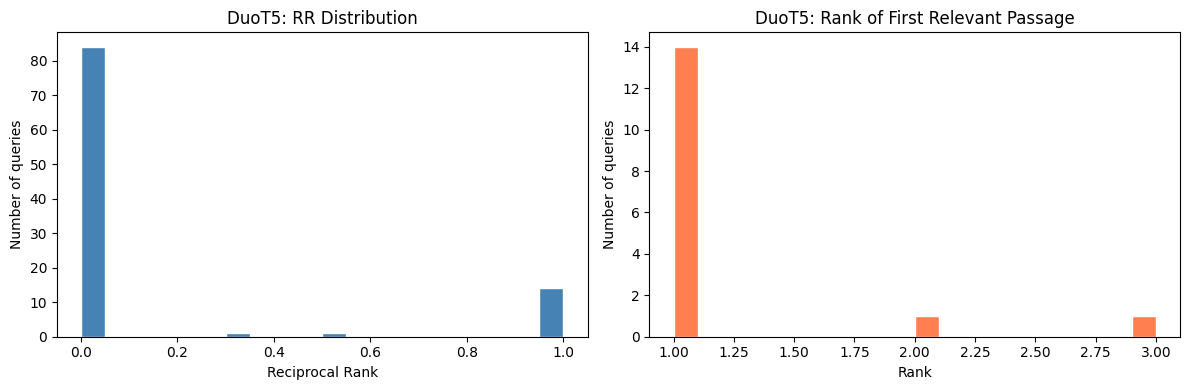

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(duo_rr_df["rr"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("DuoT5: RR Distribution")
axes[0].set_xlabel("Reciprocal Rank")
axes[0].set_ylabel("Number of queries")

axes[1].hist(duo_rr_df["first_rel_rank"].dropna(), bins=20, color="coral", edgecolor="white")
axes[1].set_title("DuoT5: Rank of First Relevant Passage")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Number of queries")

plt.tight_layout()
plt.show()

In [65]:
easy_queries_t5 = duo_rr_df[duo_rr_df["first_rel_rank"] <= 5].sort_values("rr", ascending=False)
hard_queries_t5 = duo_rr_df[(duo_rr_df["first_rel_rank"] > 5) | (duo_rr_df["first_rel_rank"].isna())].sort_values("rr")

print(f"Easy queries (relevant in top 5): {len(easy_queries_t5)}")
print(f"Hard queries (relevant outside top 5 or missing): {len(hard_queries_t5)}")

Easy queries (relevant in top 5): 16
Hard queries (relevant outside top 5 or missing): 84


In [66]:
def show_duo_example(qid, n_top=5):
    qid = str(qid)
    results = ranked_results[qid]
    query_text = query_map[qid]
    print(f"Query: {query_text}\n")
    print(f"Top {n_top} passages (DuoT5 ranked):\n")

    for entry in results[:n_top]:
        print(f"Rank {entry['rank']} | Relevant: {entry['relevant']} | Score: {entry['score']:.3f}")
        print(entry["passage"][:200])
        print("-" * 50)

    first_rel = next((entry for entry in results if entry["relevant"] == 1), None)
    if first_rel:
        print("\nFirst relevant passage:")
        print(f"Rank {first_rel['rank']} | Score: {first_rel['score']:.3f}")
        print(first_rel["passage"][:200])
    else:
        print(f"\nNo relevant passage found in top-{top_k} candidates.")

In [67]:
if len(easy_queries_t5) > 0 and len(hard_queries_t5) > 0:
    print("Easy Query Example:")
    show_duo_example(easy_queries_t5.iloc[0]["query_id"])
    print("\n" + "=" * 80 + "\n")
    print("Hard Query Example:")
    show_duo_example(hard_queries_t5.iloc[0]["query_id"])
else:
    print("Not enough easy/hard queries for qualitative examples.")

Easy Query Example:
Query: cost of attendance eastern illinois university

Top 5 passages (DuoT5 ranked):

Rank 1 | Relevant: 1 | Score: 1.000
Eastern Illinois University has roughly 8,000 students. Admission is selective. Tuition is approximately $8,550 per year for residents of Illinois and other bordering states, while it is $10,680 for n
--------------------------------------------------
Rank 2 | Relevant: 0 | Score: 0.828
The overall cost for on-campus, in-state students to attend University of Illinois at Urbana - Champaign in 2015 - 2016 was $31,796. To calculate future costs, we looked at the prior five years of dat
--------------------------------------------------
Rank 3 | Relevant: 0 | Score: 0.784
The cost of attending Northern Illinois University for in-state students without financial aid is $14,295. The cost for out-of-state students without financial aid is $23,761.
--------------------------------------------------
Rank 4 | Relevant: 0 | Score: 0.708
Related Schools. M

In [68]:
print("DuoT5 Reranker Summary:")
print(f"Candidate source: {candidate_source}")
print(f"MRR@{top_k}: {duo_rr_df['rr'].mean():.4f}")
print(f"Recall@1 (rel at rank 1): {(duo_rr_df['first_rel_rank'] == 1).mean():.1%}")
print(f"Recall@5 (rel in top 5): {(duo_rr_df['first_rel_rank'] <= 5).mean():.1%}")
print(f"Recall@10 (rel in top 10): {(duo_rr_df['first_rel_rank'] <= 10).mean():.1%}")


DuoT5 Reranker Summary:
Candidate source: monoT5 top-10
MRR@10: 0.1483
Recall@1 (rel at rank 1): 14.0%
Recall@5 (rel in top 5): 16.0%
Recall@10 (rel in top 10): 16.0%
